## Library Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


In [7]:

# ── Dataset Path ──
train_path = r'F:\B.Sc Engineering in ICE\All Lab\Neural Networks Sessional\natural_images\Train'
val_path   = r'F:\B.Sc Engineering in ICE\All Lab\Neural Networks Sessional\natural_images\Val'

# ── Data Generator ──
train_gen = ImageDataGenerator(rescale=1./255)
val_gen   = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path, target_size=(64, 64),
    batch_size=32, class_mode='categorical')

val_data = val_gen.flow_from_directory(
    val_path, target_size=(64, 64),
    batch_size=32, class_mode='categorical')

# ── Auto Class Detection ──
class_names = list(train_data.class_indices.keys())
num_classes = len(class_names)
print("Classes:", class_names)
print("Total classes:", num_classes)

Found 2094 images belonging to 3 classes.
Found 389 images belonging to 3 classes.
Classes: ['cat', 'fruit', 'person']
Total classes: 3


In [8]:


# ── CNN Model ──
model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D(2, 2),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Fully Connected
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ── Train ──
history = model.fit(train_data, epochs=10, validation_data=val_data, verbose=1)


c:\Users\User\anaconda3\envs\uzzal\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,273,923 (4.86 MB)

 Trainable params: 1,273,923 (4.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 119ms/step - accuracy: 0.8257 - loss: 0.4178 - val_accuracy: 0.9563 - val_loss: 0.1426
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.9661 - loss: 0.0920 - val_accuracy: 0.9177 - val_loss: 0.1764
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.9819 - loss: 0.0595 - val_accuracy: 0.9897 - val_loss: 0.0527
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.9866 - loss: 0.0532 - val_accuracy: 0.9897 - val_loss: 0.0672
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.9876 - loss: 0.0367 - val_accuracy: 0.9871 - val_loss: 0.0522
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.9971 - loss: 0.0110 - val_accuracy: 0.9897 - val_loss: 0.0564
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.9947 - loss: 0.0137 - val_accuracy: 0.9923 - val_loss: 0.0538
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.9995 - loss: 0.0058 - val_accuracy: 0.9820 - 

Training Accuracy   : 99.62 %
Validation Accuracy : 98.20 %


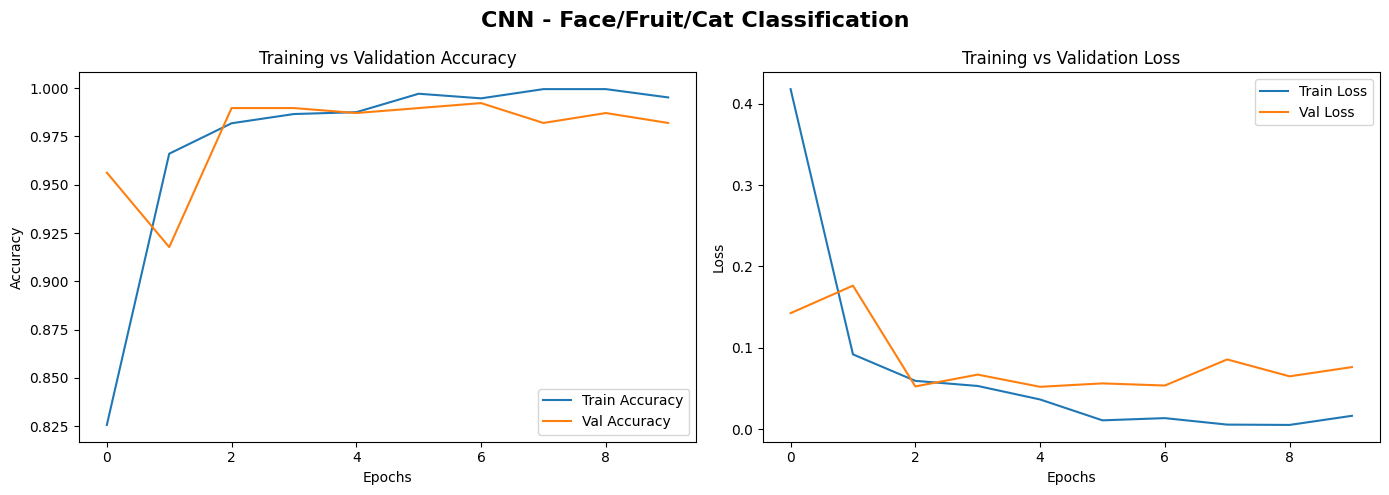

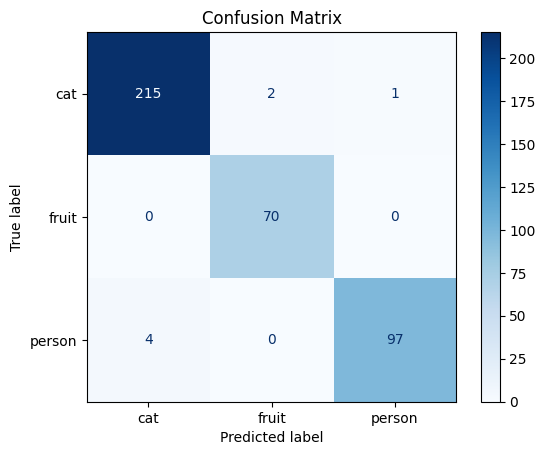


Classification Report:
              precision    recall  f1-score   support

         cat       0.98      0.99      0.98       218
       fruit       0.97      1.00      0.99        70
      person       0.99      0.96      0.97       101

    accuracy                           0.98       389
   macro avg       0.98      0.98      0.98       389
weighted avg       0.98      0.98      0.98       389



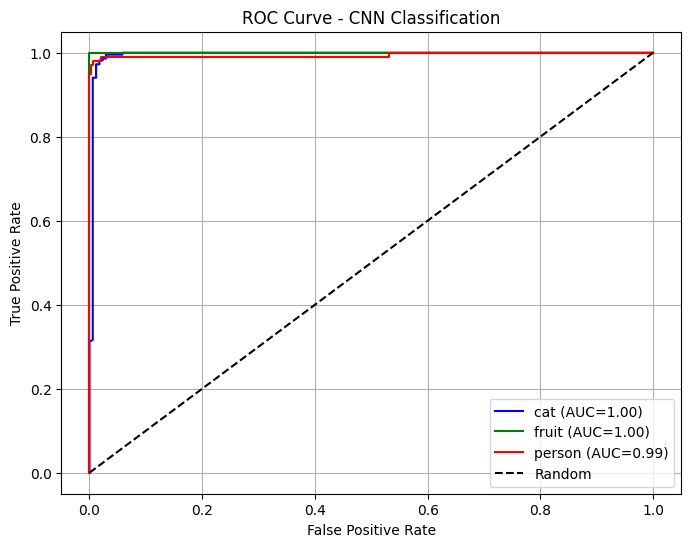

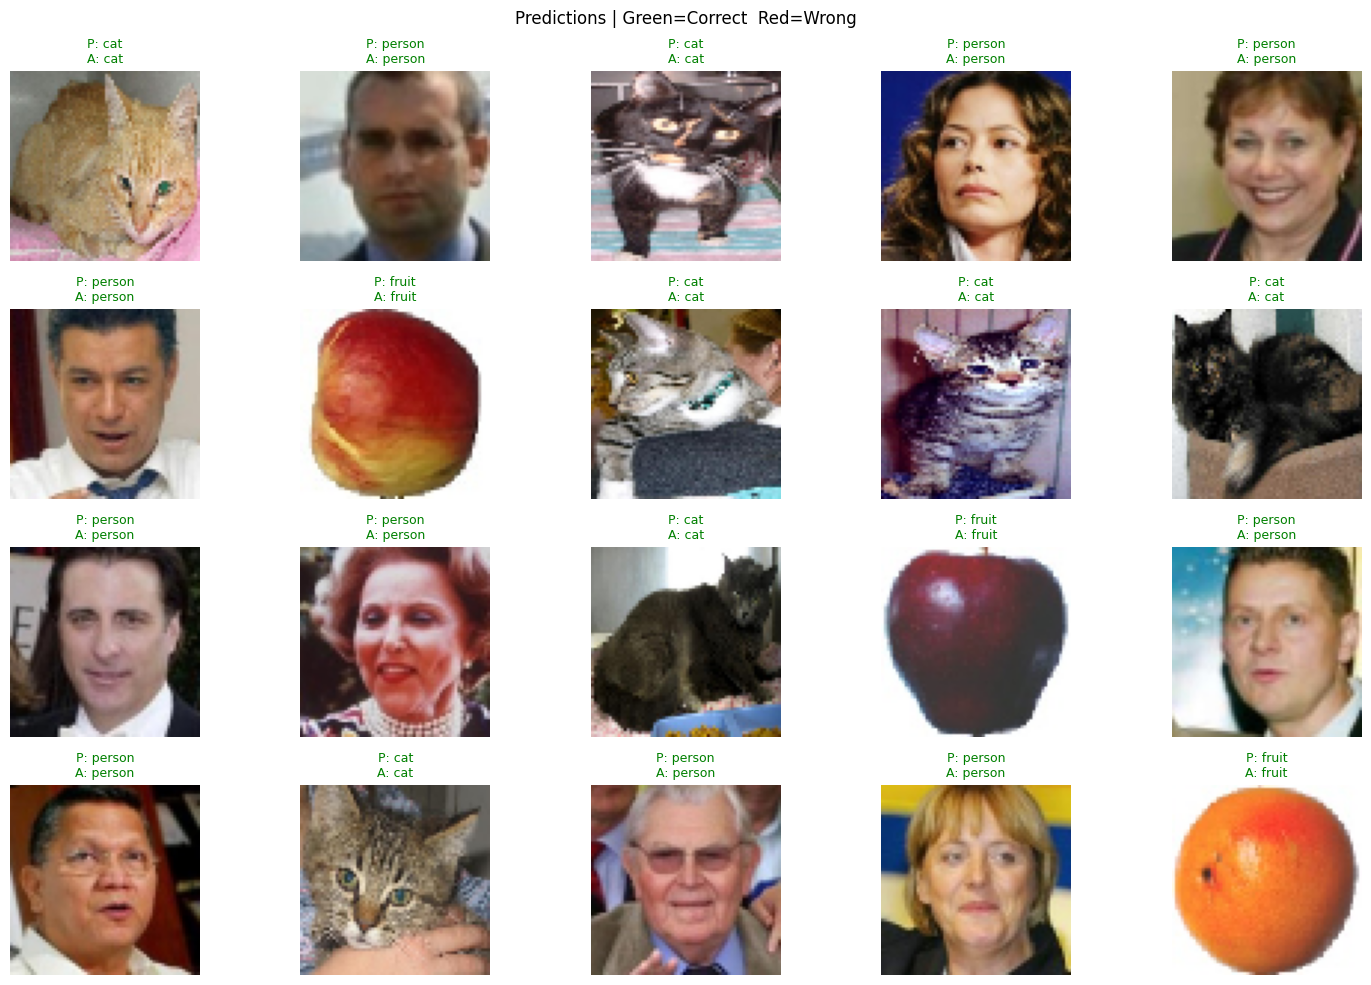

In [9]:

# ── Accuracy ──
train_acc = model.evaluate(train_data, verbose=0)[1] * 100
val_acc   = model.evaluate(val_data,   verbose=0)[1] * 100
print(f"Training Accuracy   : {train_acc:.2f} %")
print(f"Validation Accuracy : {val_acc:.2f} %")

# ── Accuracy & Loss Curve ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training vs Validation Loss')
axes[1].legend()

plt.suptitle('CNN - Face/Fruit/Cat Classification', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Confusion Matrix + ROC Data ──
y_pred, y_true, y_score = [], [], []
val_data.reset()
for X_batch, y_batch in val_data:
    probs = model.predict(X_batch, verbose=0)
    y_score.extend(probs)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(np.argmax(y_batch, axis=1))
    if len(y_true) >= val_data.samples:
        break

y_score = np.array(y_score)
y_true  = np.array(y_true)
y_pred  = np.array(y_pred)

# ── Confusion Matrix ──
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# ── Classification Report ──
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ── ROC Curve ──
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
colors = ['blue', 'green', 'red']

plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i],
             label=f"{class_names[i]} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CNN Classification')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# ── Sample Prediction ──
val_data.reset()
X_batch, y_batch = next(iter(val_data))
predictions = model.predict(X_batch, verbose=0)

plt.figure(figsize=(15, 10))
for i in range(20):
    img    = X_batch[i]
    pred   = class_names[np.argmax(predictions[i])]
    actual = class_names[np.argmax(y_batch[i])]
    plt.subplot(4, 5, i+1)
    plt.imshow(img)
    color = 'green' if pred == actual else 'red'
    plt.title(f"P: {pred}\nA: {actual}", color=color, fontsize=9)
    plt.axis('off')
plt.suptitle('Predictions | Green=Correct  Red=Wrong', fontsize=12)
plt.tight_layout()
plt.show()